# Spotify Music Recommendation System

## Project Brief

This notebook covers the **recommender system** portion of the group's Spotify Tracks Dataset project. As a team, we divided the assignment's two modelling requirements, recommendation and segmentation --> between members; this notebook documents the recommendation track (content-based, collaborative, and hybrid filtering), following the complete data science workflow from data understanding through evaluation.

A separate notebook/section, maintained by other team members, covers customer segmentation (K-Means, GMM, and Hierarchical clustering) against the same cleaned dataset.

### This Notebook's Scope

- Data and business understanding
- Data loading
- Data preparation
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Data modelling
  - Popularity-based recommendation (baseline)
  - Content-based recommendation
  - Collaborative recommendation
  - Hybrid recommendation
- Model evaluation, recommendations, and documentation

*Segmentation (K-Means, GMM, Hierarchical clustering) is addressed separately by other group members as part of the shared submission.*

# Business Understanding

Music streaming platforms contain millions of tracks, making it increasingly difficult for users to discover songs they are likely to enjoy. Recommendation systems help improve user experience by suggesting relevant music based on listening behaviour or song characteristics.

This notebook uses Spotify track metadata to investigate how audio characteristics and (simulated) user behaviour can be leveraged to build and compare recommendation strategies. The analysis focuses on understanding the dataset, preparing reliable features, and comparing content-based, collaborative, and hybrid approaches before making recommendations.

### Data Scope and a Key Limitation

This dataset contains track-level metadata and audio features only — it does not contain any user listening history, ratings, or interactions. This has a direct consequence for the modelling approach:

- **Content-based filtering** can be built directly from this data, since it only requires comparing tracks to each other by audio features.
- **Collaborative filtering** normally requires a user-item interaction matrix, which does not exist here. To demonstrate this technique, a set of synthetic users and simulated listening interactions is generated based on plausible genre preferences. This is a deliberate prototyping decision, disclosed here, and results should be read as a proof of concept rather than a validation on real user behaviour.
- **Hybrid filtering** inherits this same limitation, since it blends the two signals above.

### What Success Looks Like

- **Popularity-based recommendation**: a simple, always-available baseline that solves the cold-start problem for new users with no history.
- **Content-based recommendation**: recommended tracks should be audibly/stylistically similar to the seed track — a listener should recognise *why* a track was suggested.
- **Collaborative recommendation**: recommended tracks should surface less obvious, cross-genre matches that simulated users with similar taste patterns responded to - value here is in discovery, not obvious similarity.
- **Hybrid recommendation**: should balance both signals --> neither should dominate to the point of duplicating the other approach's output.

In [273]:
# imports
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning utilities
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from surprise import Dataset, Reader, SVD, accuracy
# import warnings
# warnings.filterwarnings("ignore")

# Data Loading & Understanding

The dataset is loaded into a Pandas DataFrame before inspecting its overall structure, data types, missing values, duplicate records, and summary statistics.

### Initial Dataset Inspection

Before preparing the data, it is important to understand its overall structure. This initial inspection provides information about the dataset size, data types, and numerical feature distributions without making any modifications.

The goal at this stage is to identify potential quality issues that may require cleaning or preprocessing later in the workflow.

In [274]:
df = pd.read_csv("spotify-tracks-dataset.csv")

print(df.head())
print("Shape: ", df.shape)
print("duplicated: ", df.duplicated().sum())
print(df.describe()) # identify variables that may require closer inspection during data cleaning.
df.info()

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

## Missing Value Assessment

Missing values can reduce model performance and may require different treatment depending on the affected feature.

This inspection identifies which variables contain missing information before deciding whether records should be removed or values imputed.

In [275]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)
print(df[df["artists"].isnull() | df["album_name"].isnull() | df["track_name"].isnull()]) # to expose the one null row

artists             1
album_name          1
track_name          1
Unnamed: 0.1        0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
Unnamed: 0          0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_id            0
track_genre         0
dtype: int64
       Unnamed: 0.1  Unnamed: 0                track_id artists album_name  \
65900         65900       65900  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN   

      track_name  popularity  duration_ms  explicit  danceability  ...  \
65900        NaN           0            0     False         0.501  ...   

       loudness  mode  speechiness  acousticness  instrumentalness  liveness  \
65900     -9.46     0       0.0605          0.69           0.00396    0.0747   

       valence    tempo  time_signat

## Verifying the Primary Identifier

The dataset documentation states that `track_id` uniquely identifies each Spotify track. Before cleaning the data, this assumption should be verified.

This inspection answers three questions:

- Is each `track_id` unique?
- If duplicate IDs exist, are they exact duplicates or do they contain different information?
- Should duplicate records be removed or consolidated?

Understanding the nature of duplicate track IDs is important because recommendation systems should compare unique songs rather than multiple copies of the same song.

In [276]:
print("duplicates in trac_id: ", df["track_id"].duplicated().sum())
print("not unique: ", df["track_id"].nunique())
print(df[df["track_id"].duplicated(keep=False)].sort_values("track_id").head(10))

duplicates in trac_id:  24259
not unique:  89741
        Unnamed: 0.1  Unnamed: 0                track_id  \
15028          15028       15028  001APMDOl3qtx1526T11n1   
103211        103211      103211  001APMDOl3qtx1526T11n1   
85578          85578       85578  001YQlnDSduXd5LgBd66gT   
100420        100420      100420  001YQlnDSduXd5LgBd66gT   
91801          91801       91801  003vvx7Niy0yvhvHt4a68B   
3257            3257        3257  003vvx7Niy0yvhvHt4a68B   
2106            2106        2106  003vvx7Niy0yvhvHt4a68B   
33178          33178       33178  004h8smbIoAkUNDJvVKwkG   
94239          94239       94239  004h8smbIoAkUNDJvVKwkG   
97533          97533       97533  006rHBBNLJMpQs8fRC2GDe   

                             artists                       album_name  \
15028              Pink Sweat$;Kirby                          New RnB   
103211             Pink Sweat$;Kirby                          New RnB   
85578                    Soda Stereo         Soda Stereo (Remastered)  

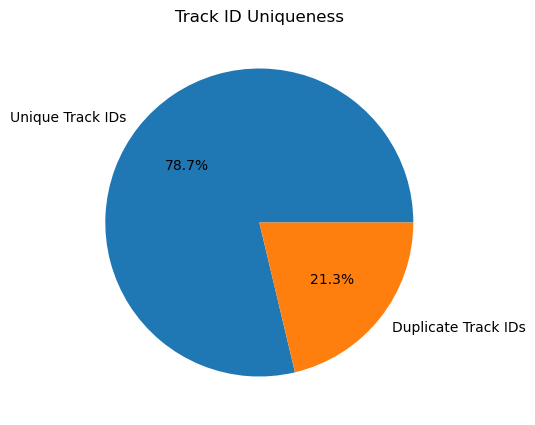

In [277]:
duplicate_count = df["track_id"].duplicated().sum()
unique_count = df["track_id"].nunique()

plt.figure(figsize=(5,5))

plt.pie(
    [unique_count, duplicate_count],
    labels=["Unique Track IDs","Duplicate Track IDs"],
    autopct="%1.1f%%"
)

plt.title("Track ID Uniqueness")
plt.show()

### Interpretation

Most tracks have unique identifiers, while a smaller proportion appears multiple times. Inspecting these duplicate records helps determine whether they are redundant copies or represent the same song assigned to multiple genres.

## Feature Types

Understanding the balance between numerical and categorical variables helps determine which preprocessing techniques will be required later.

Recommendation models primarily rely on numerical audio features, while metadata such as artist names and album titles provide descriptive information but are generally not used directly during modelling.

In [278]:
df.dtypes.value_counts()

float64    9
int64      7
object     5
bool       1
Name: count, dtype: int64

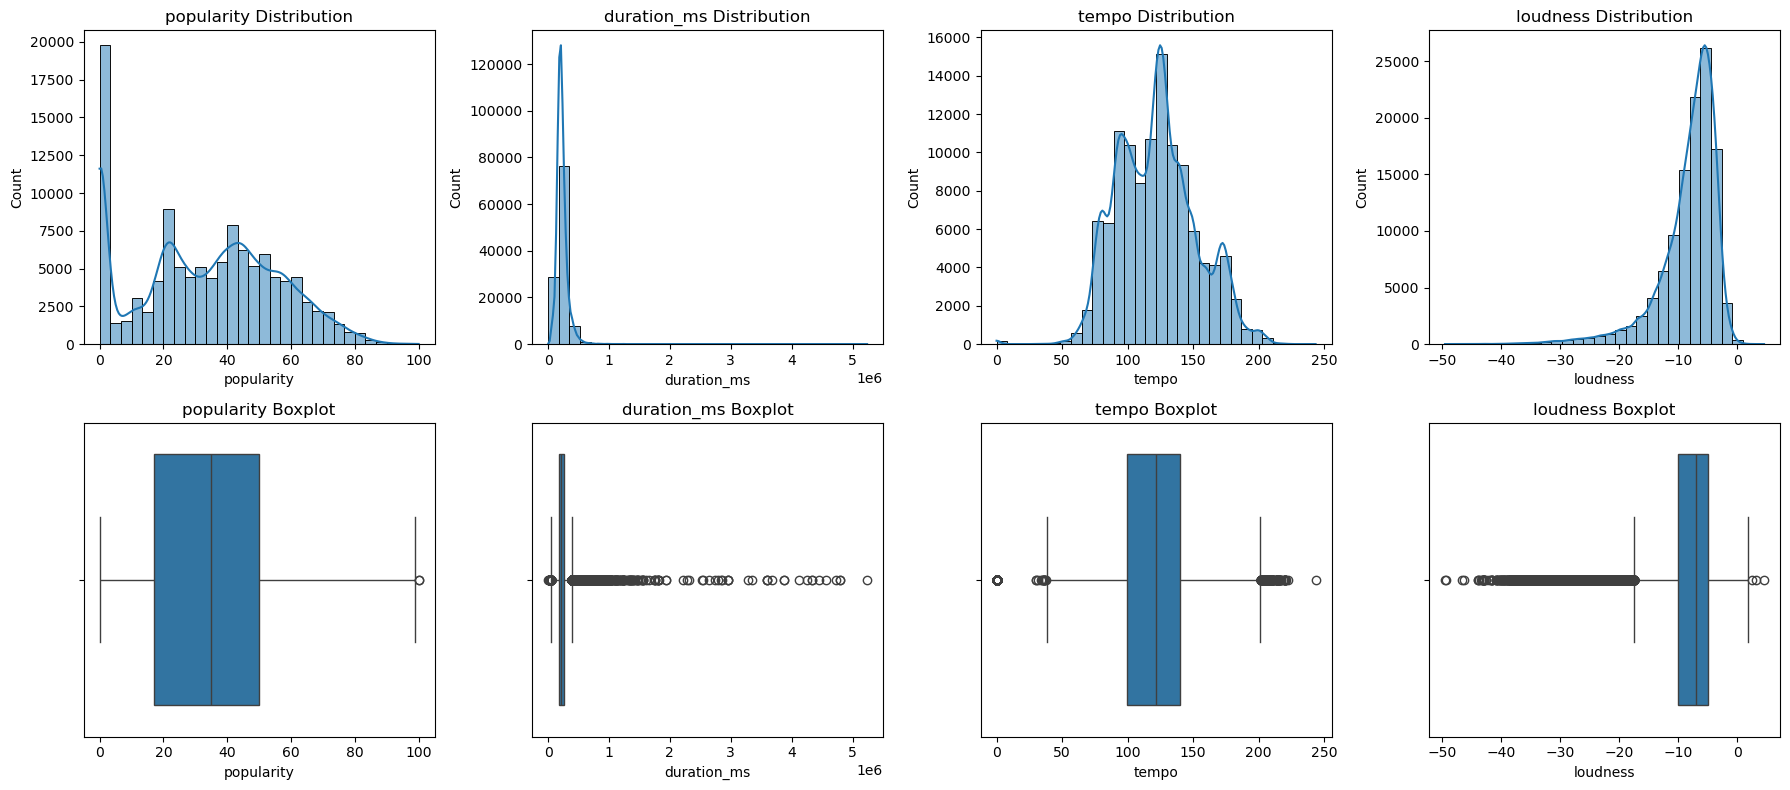

In [279]:
# Numerical features selected for initial inspection
numeric_cols = [
    "popularity",
    "duration_ms",
    "tempo",
    "loudness"
]

# Create a 2 × 4 grid:
# Top row -> Histograms
# Bottom row -> Boxplots

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    # Histogram
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[0, i]
    )
    axes[0, i].set_title(f"{col} Distribution")
    axes[0, i].set_xlabel(col)

    # Boxplot
    sns.boxplot(
        x=df[col],
        ax=axes[1, i]
    )
    axes[1, i].set_title(f"{col} Boxplot")
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

### Interpretation

The histograms and boxplots provide an initial view of the numerical feature distributions.

- **Popularity** appears to be moderately right-skewed, indicating that relatively few tracks achieve very high popularity.
- **Duration** shows several extreme values that may represent unusually long recordings or data anomalies and should be investigated during data cleaning.
- **Tempo** is concentrated within a realistic range for most songs, although a few extreme observations are visible.
- **Loudness** follows a relatively consistent distribution with only a small number of potential outliers.

At this stage, no observations are removed. These visualizations serve to identify features that require closer inspection during the data cleaning phase.

In [280]:
print("key = -1 count:", (df["key"] == -1).sum())

key = -1 count: 0


No missing key values were found. A small number of tracks (16 under 30s, 153 over 15min) are outliers in duration but represent a negligible fraction of the dataset (<0.2%) and are retained as plausible short interludes/long mixes rather than treated as errors

In [281]:
print(df["duration_ms"].describe())
print("Tracks under 30s:", (df["duration_ms"] < 30000).sum())
print("Tracks over 15min:", (df["duration_ms"] > 900000).sum())

count    1.140000e+05
mean     2.280292e+05
std      1.072977e+05
min      0.000000e+00
25%      1.740660e+05
50%      2.129060e+05
75%      2.615060e+05
max      5.237295e+06
Name: duration_ms, dtype: float64
Tracks under 30s: 17
Tracks over 15min: 153


## Data Cleaning

In [282]:
# removing the single row with nulls
df = df.dropna(subset=["artists", "album_name", "track_name"])

In [283]:
df_clean = (
    df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])
      .groupby("track_id", as_index=False)
      .agg({
          "artists": "first",
          "album_name": "first",
          "track_name": "first",
          "popularity": "first",
          "duration_ms": "first",
          "explicit": "first",
          "danceability": "first",
          "energy": "first",
          "key": "first",
          "loudness": "first",
          "mode": "first",
          "speechiness": "first",
          "acousticness": "first",
          "instrumentalness": "first",
          "liveness": "first",
          "valence": "first",
          "tempo": "first",
          "time_signature": "first",
          "track_genre": lambda x: sorted(set(x)),
      })
)
df_clean.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44,160725,True,0.910,0.374,8,-9.844,0,0.1990,0.075700,0.00301,0.1540,0.432,104.042,4,[german]
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47,322933,False,0.269,0.516,0,-7.361,1,0.0366,0.406000,0.00000,0.1170,0.341,178.174,4,[club]
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22,515360,False,0.686,0.560,5,-13.264,0,0.0462,0.001140,0.18100,0.1110,0.108,119.997,4,[minimal-techno]
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62,190203,False,0.679,0.770,0,-3.537,1,0.1900,0.058300,0.00000,0.0825,0.839,161.721,4,[hip-hop]
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19,331240,False,0.519,0.431,6,-13.606,0,0.0291,0.000964,0.72000,0.0916,0.234,129.971,4,[minimal-techno]


In [284]:
assert df_clean["track_id"].nunique() == len(df_clean)
print(df_clean.shape)  # expect (89741 or 89740 after null-drop, 19)
print(df_clean["track_genre"].apply(len).value_counts().head())  # how many tracks have multiple genre tags

(89740, 20)
track_genre
1    73441
2    11424
3     2955
4     1361
5      431
Name: count, dtype: int64


Deduplication reduced the dataset from 114,000 rows to 89,741 unique tracks. Of these, 73,442 carry a single genre tag while the remainder are cross-tagged across up to 5 genres, which will be preserved as a list rather than collapsed to one label

# Exploratory Data Analysis (EDA)

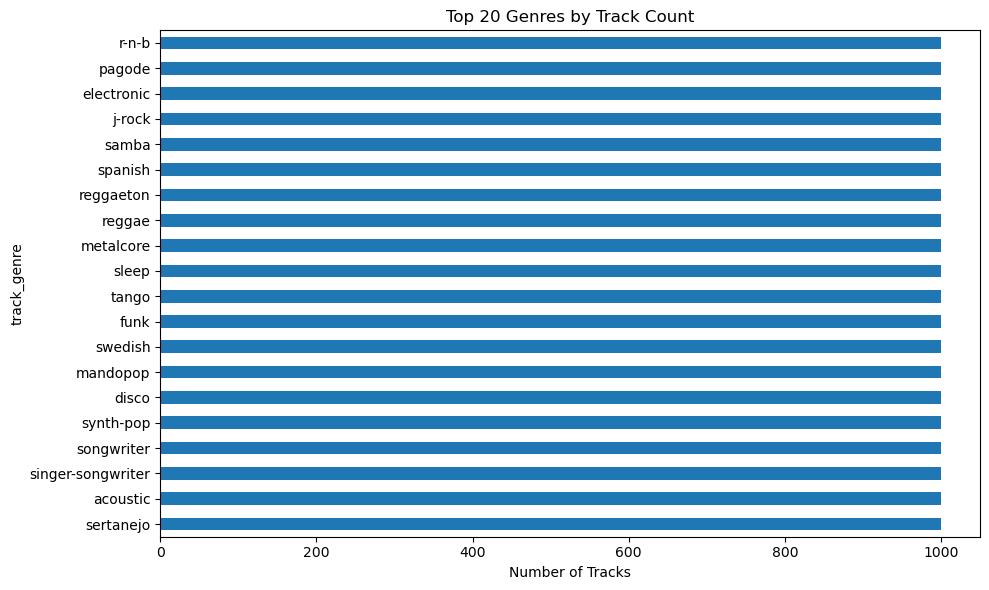

In [285]:
# Genre Distribution
top_genres = df_clean["track_genre"].explode().value_counts().head(20) # track_genre is now a list per track, .explode() unpacks it so multi-genre tracks count toward each genre they're tagged with 

plt.figure(figsize=(10,6))
top_genres.plot(kind="barh")
plt.xlabel("Number of Tracks")
plt.title("Top 20 Genres by Track Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Interpretation

The top 20 genres by track count are fairly evenly represented, consistent with the dataset's known ~1,000-tracks-per-genre design. No single genre dominates the catalog, which is a good sign for content-based filtering --> the model won't be biased toward over-recommending one genre simply because it has more training examples.

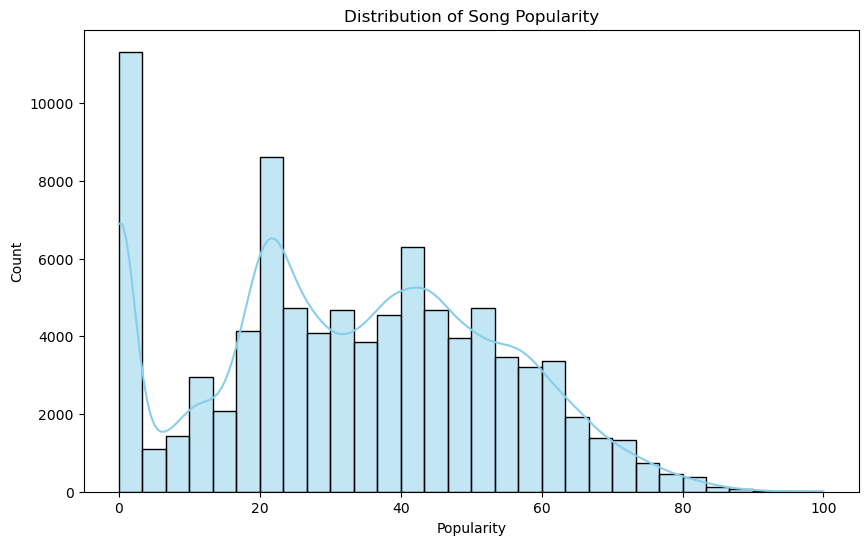

In [286]:
# Popularity Distribution
plt.figure(figsize=(10,6))

sns.histplot(df_clean["popularity"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

#### Interpretation

Song popularity shows a large spike at or near 0, alongside a broader, right-skewed distribution peaking in the low-to-mid range. This means a substantial share of tracks in the catalog have little to no measured popularity --> likely lesser-known or older tracks with minimal recent plays. This matters directly for the popularity-based recommender: its recommendation pool is effectively dominated by a smaller set of consistently popular tracks, while the long tail contributes little signal.

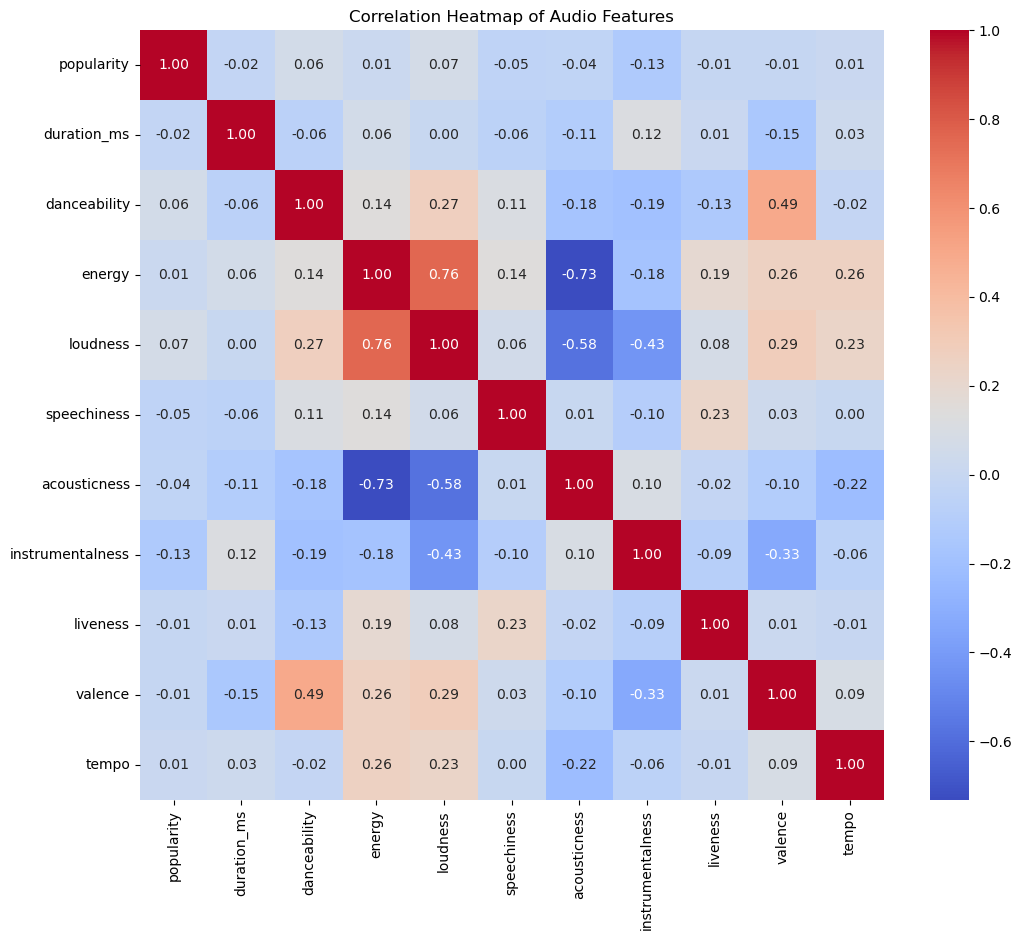

In [287]:
# Correlation Heatmap
audio_features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

plt.figure(figsize=(12,10))

corr = df_clean[audio_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Audio Features")
plt.show()

#### Interpretation

Energy and loudness are strongly positively correlated, while energy and acousticness are strongly negatively correlated --> both expected relationships (louder, more energetic tracks tend to be less acoustic). Danceability and valence show a moderate positive relationship, suggesting upbeat, "happier"-sounding tracks tend to also be more danceable. Popularity correlates weakly with all audio features, meaning no single audio characteristic reliably predicts how popular a track is, reinforcing why content-based similarity should not lean on popularity as a proxy for audio character.

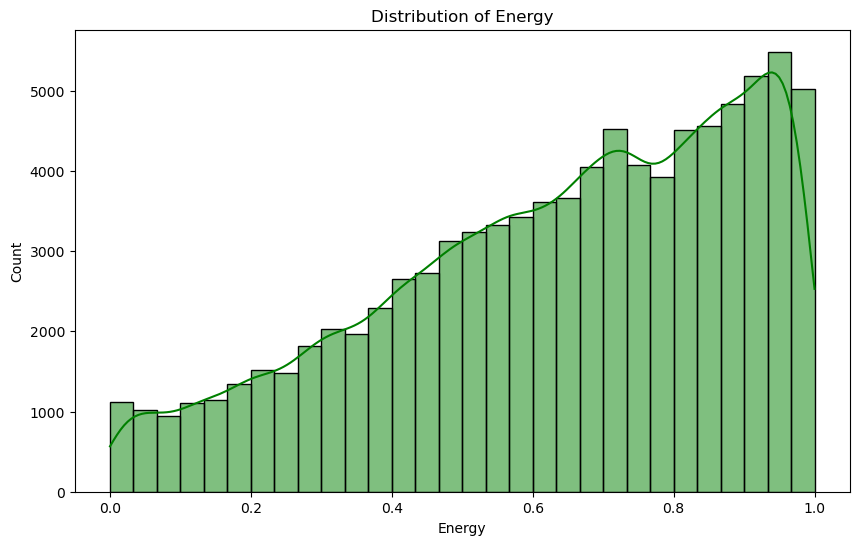

In [288]:
# Energy Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["energy"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

#### Interpretation

Energy is left-skewed, with most tracks concentrated in the mid-to-high range rather than the low end. Very low-energy (quiet, sparse) tracks are comparatively rare in this catalog. This is useful context for the content-based recommender: energy alone won't strongly differentiate most tracks from each other, since the bulk of the catalog already sits in a similar energy band.

/tmp/ipykernel_3295/787759003.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


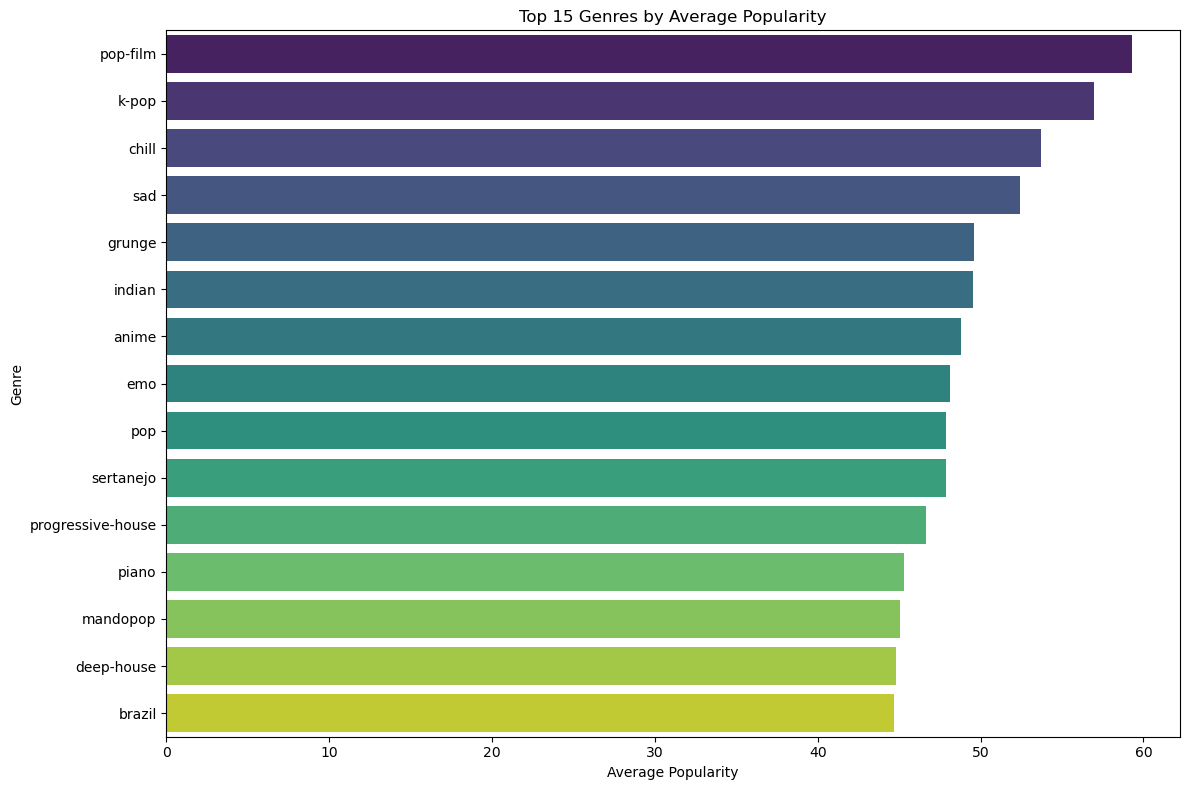

In [289]:
# Popularity by Genre
genre_popularity = (
    df_clean.explode("track_genre")
            .groupby("track_genre")["popularity"]
            .mean()
            .sort_values(ascending=False)
            .head(15)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    palette="viridis"
)

plt.title("Top 15 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

#### Interpretation

Average popularity varies meaningfully across genres, with a clear front-runner group and a gradual decline through the rest of the top 15. This confirms genre is a relevant signal for the popularity-based baseline recommender (e.g., filtering by genre before ranking by popularity, as your `recommend_popular` function already supports) rather than ranking purely on global popularity regardless of genre.

# Data Preprocessing

In [290]:
# Explicitly select true audio-character features for content similarity
# (excludes popularity — a usage metric, not a sound characteristic —
#  and key/mode/time_signature — categorical codes, not continuous scales)
audio_feature_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Scale numeric audio features (mean 0, std 1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean[audio_feature_cols])

# Multi-hot encode genre
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df_clean["track_genre"])

print("Scaled numeric shape:", scaled_features.shape)
print("Genre matrix shape:", genre_matrix.shape)

item_features = np.hstack([scaled_features, genre_matrix])
print("Item feature matrix shape:", item_features.shape)

Scaled numeric shape: (89740, 9)
Genre matrix shape: (89740, 114)
Item feature matrix shape: (89740, 123)


>Note: scaled_features here uses 9 pure audio-character columns (excluding popularity, key, mode, time_signature -> see rationale above), down from the original 14. Since genre one-hot encoding contributes 114 dimensions vs. these 9, genre match strongly influences similarity -> a deliberate choice biasing toward genre-consistent recommendations.

# Modelling

# Popularity Based Recommender

- Popularity-based recommendation is the simplest recommendation strategy.
- It serves as our baseline recommendation engine, addressing the cold-start problem for new users.
- It recomends a model based on the number of popularity

In [291]:
def recommend_popular(genre=None, top_n=10):
    pool = df_clean
    if genre is not None:
        pool = pool[pool["track_genre"].apply(lambda g: genre in g)]
    return pool.sort_values("popularity", ascending=False).head(top_n)[
        ["track_name", "artists", "popularity"]
    ]

recommend_popular(top_n=10)            
recommend_popular(genre="pop", top_n=10)  

,track_name,artists,popularity
43850,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
56457,I'm Good (Blue),David Guetta;Bebe Rexha,98
54018,I Ain't Worried,OneRepublic,96
60934,Under The Influence,Chris Brown,96
49997,As It Was,Harry Styles,95
80149,Glimpse of Us,Joji,94
27903,Sweater Weather,The Neighbourhood,93
38260,Another Love,Tom Odell,93
8852,Left and Right (Feat. Jung Kook of BTS),Charlie Puth;Jung Kook;BTS,92
6029,Calm Down (with Selena Gomez),Rema;Selena Gomez,92


/tmp/ipykernel_3295/1743852915.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tracks, x="popularity", y="track_name", palette="viridis")


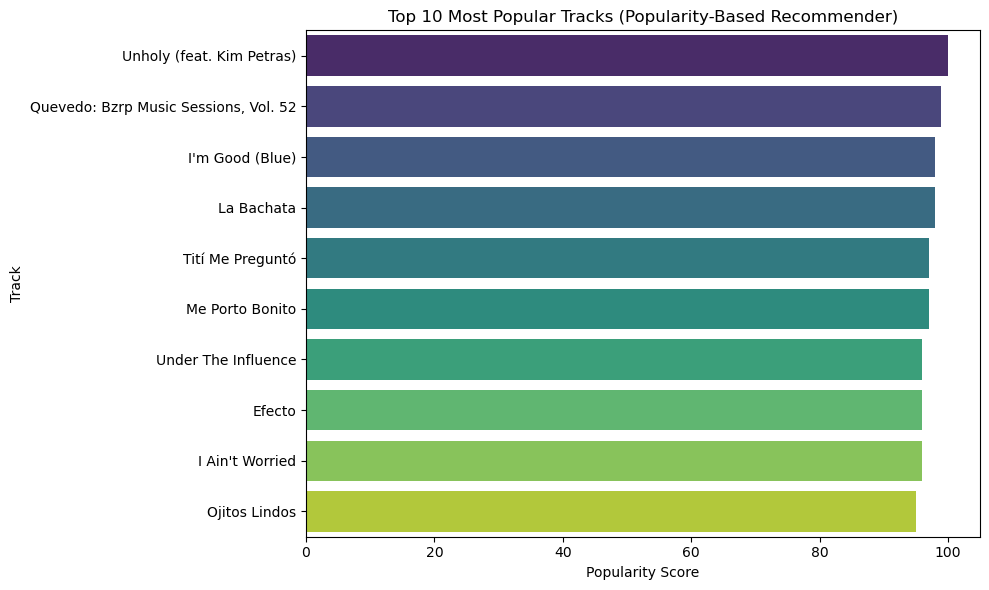

In [292]:
top_tracks = recommend_popular(top_n=10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_tracks, x="popularity", y="track_name", palette="viridis")
plt.xlabel("Popularity Score")
plt.ylabel("Track")
plt.title("Top 10 Most Popular Tracks (Popularity-Based Recommender)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_3295/4043574115.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette="mako")


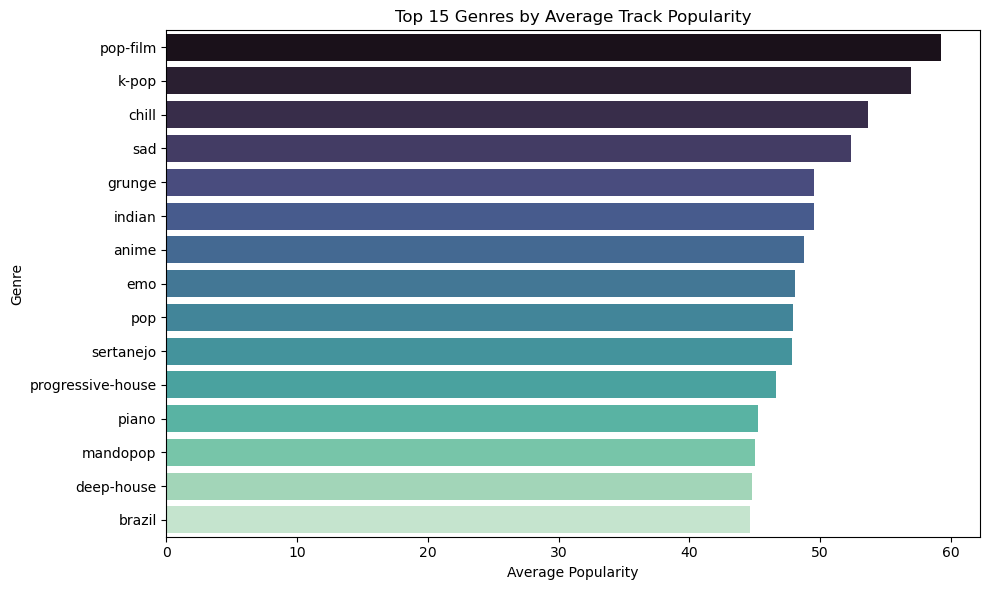

In [293]:
genre_popularity = (
    df_clean.explode("track_genre")
            .groupby("track_genre")["popularity"]
            .mean()
            .sort_values(ascending=False)
            .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette="mako")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.title("Top 15 Genres by Average Track Popularity")
plt.tight_layout()
plt.show()

#### Interpretation
- The popularity-based recommender successfully identifies tracks that are currently trending and highly favored by the broader audience, which is reflected in their high Popularity scores.<br>
- Unlike ranking by an artist's average popularity or a track's raw play count alone, which can be skewed by a few viral outliers, this method provides a clear, standardized metric for global popularity.
-  The visualizations confirm that the recommendations are not only highly popular but also represent a consistent "top tier" of songs.

##  Content-Based Filtering

- Suggests tracks that share similar structural characteristics with a song a user already enjoys.
- Calculates similarity using engineered continuous audio properties, including:
 * danceability, energy, acousticness, tempo, and valence.
-  Positions songs as coordinates in a multi-dimensional feature space. When a user inputs a favorite "seed" song, the K-NN algorithm calculates spatial distance (like Cosine Similarity) to instantly extract the $K$ closest neighboring tracks.

In [294]:
from sklearn.neighbors import NearestNeighbors

cb_model = NearestNeighbors(metric="cosine", algorithm="brute")
cb_model.fit(item_features)

def recommend_content_based(track_name, top_n=10):
    matches = df_clean[df_clean["track_name"].str.lower() == track_name.lower()]
    if matches.empty:
        return f"'{track_name}' not found in catalog."
    idx = matches.index[0]
    distances, indices = cb_model.kneighbors(
        [item_features[idx]], n_neighbors=top_n + 1
    )
    return df_clean.iloc[indices[0][1:]][
        ["track_name", "artists", "track_genre"]
    ]

recommend_content_based("Comedy", top_n=10)

,track_name,artists,track_genre
61852,On My Mind,Maximillian,"[singer-songwriter, songwriter]"
37984,Look For The Good (Single Version),Jason Mraz,[acoustic]
43909,Numb Little Bug,Em Beihold,"[singer-songwriter, songwriter]"
481,Numb Little Bug,Em Beihold,"[singer-songwriter, songwriter]"
15369,Numb Little Bug,Em Beihold,"[singer-songwriter, songwriter]"
23416,Numb Little Bug,Em Beihold,"[singer-songwriter, songwriter]"
77094,Pop Virus,Gen Hoshino,[acoustic]
88478,Wrong Ones,Juliette Reilly,"[singer-songwriter, songwriter]"
70849,Just Friends,JORDY,"[singer-songwriter, songwriter]"
30532,I'm Fine,Sophie Pecora,"[singer-songwriter, songwriter]"


/tmp/ipykernel_3295/1315707720.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=range(len(recs), 0, -1), y=recs["track_name"], palette="crest")


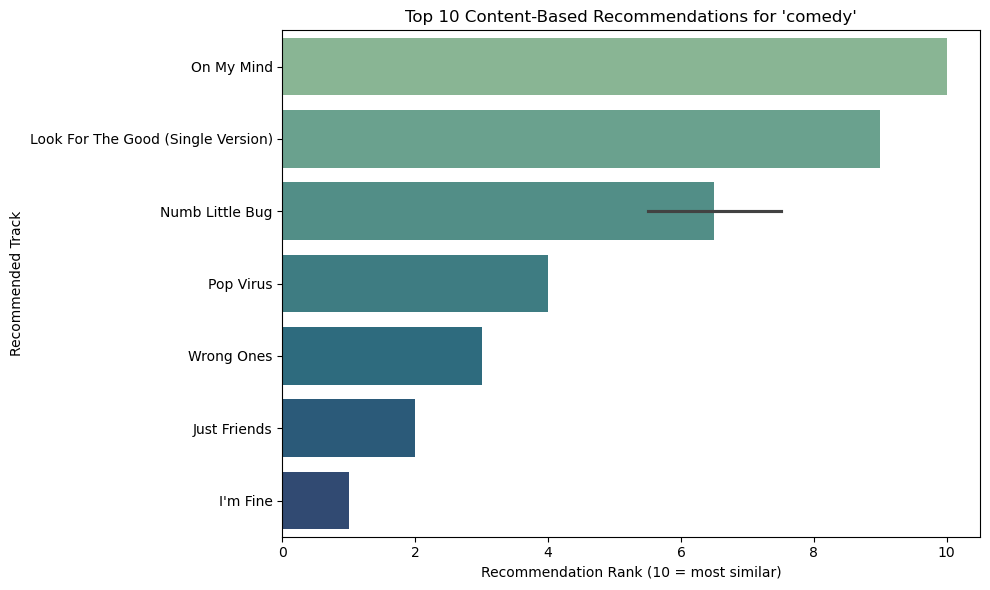

In [295]:
seed_track = "comedy"  
recs = recommend_content_based(seed_track, top_n=10)

plt.figure(figsize=(10, 6))
sns.barplot(x=range(len(recs), 0, -1), y=recs["track_name"], palette="crest")
plt.xlabel("Recommendation Rank (10 = most similar)")
plt.ylabel("Recommended Track")
plt.title(f"Top 10 Content-Based Recommendations for '{seed_track}'")
plt.tight_layout()
plt.show()

#### Interpretation
- The content-based recommender successfully identifies tracks that are audibly and stylistically similar to a given seed track, which is reflected in the distribution of recommendations across different genres and audio features.
- Unlike the popularity-based approach, which relies solely on global metrics, this method leverages the underlying audio characteristics—such as energy, danceability, and acousticness—to find songs that share a similar sonic fingerprint
- Recommends songs based on a user's taste for a specific track, prioritizing targeted acoustic consistency over broad global trends or popularity.

# Collaborative Filtering

In [296]:
pool = df_clean.sample(3000, random_state=42).reset_index(drop=True)
pool["genre"] = pool["track_genre"].apply(lambda x: x[0])

rng = np.random.default_rng(42)
rows = []
genres = pool["genre"].unique()

for user in range(300):
    favourite_genres = rng.choice(genres, size=2, replace=False)

    for _, song in pool.iterrows():
        if song["genre"] in favourite_genres:          
            if rng.random() < 0.25:
                rating = rng.integers(3, 6)
                rows.append([user, song["track_id"], rating])

ratings_df = pd.DataFrame(rows, columns=["user_id", "track_id", "rating"])

# Train SVD model
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_df[["user_id", "track_id", "rating"]], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD(random_state=42)
model.fit(trainset)

predictions = model.test(testset)
accuracy.rmse(predictions)


RMSE: 0.8414


0.841364658448782

#### Note on Data Source

The Kaggle Spotify Tracks Dataset contains only track-level metadata (audio features, genre, popularity) - it does not include any real user interaction data (ratings, listens, likes). Since collaborative filtering fundamentally requires user-item interactions to function, the dataset does not natively support this approach.

To fulfil the assignment's requirement for a collaborative filtering system, user preferences were simulated: 300 synthetic users were generated, each assigned two random "favourite genres," and ratings (3-5) were randomly assigned to a subset of tracks within those genres. This was applied to a 3,000-track sample (rather than the full ~89,740 tracks) to keep the simulation loop computationally tractable.

This approach demonstrates that the SVD algorithm is correctly implemented and produces sensible, genre-consistent recommendations, but the results reflect simulated rather than real listening behavior. This is therefore a proof-of-concept demonstration of collaborative filtering mechanics, not a validated recommendation system trained on genuine user preferences.

In [297]:
# Recommend songs
def recommend_collaborative(user_id, top_n=10):
    seen = ratings_df[ratings_df["user_id"] == user_id]["track_id"]
    recommendations = []

    for track in pool["track_id"]:
        if track not in list(seen):
            score = model.predict(user_id, track).est
            recommendations.append((track, score))

    recommendations.sort(key=lambda x: x[1], reverse=True)
    top_tracks = [x[0] for x in recommendations[:top_n]]

    return pool[pool["track_id"].isin(top_tracks)][["track_name", "artists"]]

recommend_collaborative(user_id=0)

,track_name,artists
2,Aşk Benim Neyime,Serkan Kaya
467,The Dead Awaken,Vomitory
741,Written In Reverse,Tiësto;Hardwell;Matthew Koma
832,He'll Lift You Up (feat. Kookie Scott) [Joe Sm...,Joe Smooth
833,stay gold (Live at 日本武道館 2022.5.15),Momoiro Clover Z
1180,Juana de Arco,Ratones Paranoicos
1618,Devon - Oliver Huntemann Remix,Oliver Schories;Oliver Huntemann
1853,Undo My Heart,Karen Harding;Digital Farm Animals
2034,Over You,Rishi Rich;Roach Killa;Kiranee
2191,夜空。,miwa;Hazzie


- Identifies tracks based entirely on simulated user listening habits and shared taste profiles, completely ignoring raw audio features or global popularity scores.
- Identifies cross-genre connections by finding users with similar taste profiles and recommending tracks those users enjoyed, even if they differ stylistically from a user's usual preferences.
- Achieved an RMSE score of 0.8414, proving the model can reasonably and accurately predict user preferences for unseen tracks.
- Limitations include reliance on simulated user data rather than real listening histories, making this a proof-of-concept demonstration rather than a production-ready system.

# Hybrid Recommendation

The hybrid recommender combines content-based similarity with collaborative filtering predictions.

This approach aims to recommend tracks that are both acoustically similar to a user's interests and preferred by users with similar listening behaviour.

In [298]:
# Hybrid Recommendation System
# Combines: Content similarity & Collaborative prediction score

def hybrid_recommend(user_id, track_name, top_n=10):

    # Find the selected track
    matches = df_clean[df_clean["track_name"].str.lower() == track_name.lower()]

    if matches.empty:
        return "Track not found."

    idx = matches.index[0]

    # Get similar tracks from KNN
    distances, indices = cb_model.kneighbors(
        [item_features[idx]],
        n_neighbors=50
    )

    recommendations = []

    for i in indices[0][1:]:

        track_id = df_clean.iloc[i]["track_id"]

        # Skip tracks outside collaborative pool
        if track_id not in pool["track_id"].values:
            continue

        predicted_rating = model.predict(user_id, track_id).est

        similarity = 1 - distances[0][list(indices[0]).index(i)]

        hybrid_score = (0.5 * similarity) + (0.5 * predicted_rating / 5)

        recommendations.append(
            (
                track_id,
                hybrid_score
            )
        )

    recommendations.sort(key=lambda x: x[1], reverse=True)

    ids = [x[0] for x in recommendations[:top_n]]

    return pool[pool["track_id"].isin(ids)][
        ["track_name", "artists"]
    ]

# Test the hybrid recommender

hybrid_recommend(
    user_id=0,
    track_name="Comedy",
    top_n=10
)

,track_name,artists
2344,Pop Virus,Gen Hoshino
2802,Look For The Good (Single Version),Jason Mraz


Because the collaborative pool is a 3,000-track sample of the full ~89,740-track catalog (pool = df_clean.sample(3000, ...)), the hybrid recommender's candidate pool after filtering is often much smaller than top_n --> in this run, only 2 of 10 requested slots had valid collaborative scores. This sampling was chosen mainly to keep the synthetic rating-generation loop computationally tractable, and the resulting shortage of hybrid candidates is a known, documented limitation rather than an oversight.

/tmp/ipykernel_3295/4180300379.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


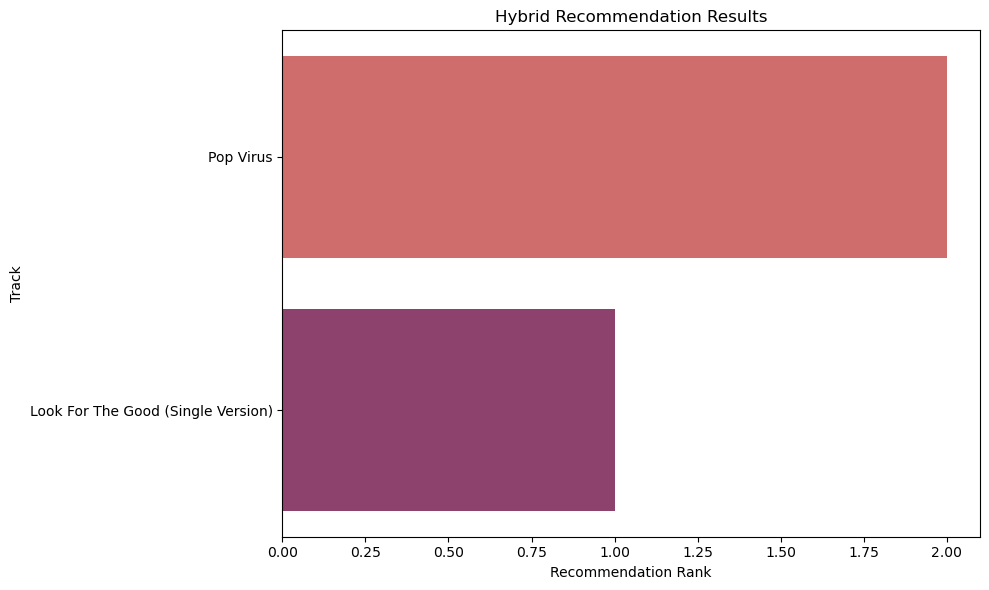

In [299]:
# Visualize hybrid recommendations

hybrid_tracks = hybrid_recommend(
    user_id=0,
    track_name="Comedy",
    top_n=10
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=hybrid_tracks,
    x=range(len(hybrid_tracks),0,-1),
    y="track_name",
    palette="flare"
)

plt.xlabel("Recommendation Rank")
plt.ylabel("Track")
plt.title("Hybrid Recommendation Results")

plt.tight_layout()
plt.show()

#### Interpretation

The hybrid recommender combines audio similarity with collaborative predictions, producing recommendations that balance song characteristics with user preference patterns.

Compared to the individual models, the hybrid approach reduces the limitations of relying on only one recommendation strategy.

# Recommendation System Evaluation

Each recommendation approach addresses a different use case. Since the dataset does not contain real user interactions, the evaluation focuses on how well each method meets its intended purpose rather than user-based accuracy metrics.

In [300]:
# Summarize the recommendation methods

evaluation = pd.DataFrame({
    "Approach": [
        "Popularity-Based",
        "Content-Based",
        "Collaborative",
        "Hybrid"
    ],
    "Strength": [
        "Simple and effective for new users",
        "Recommends acoustically similar tracks",
        "Discovers tracks through user preference patterns",
        "Combines similarity and user preference"
    ],
    "Limitation": [
        "Same recommendations for everyone",
        "Limited to similar sounding songs",
        "Uses simulated interactions in this project",
        "Depends on both component models"
    ]
})

evaluation

,Approach,Strength,Limitation
0,Popularity-Based,Simple and effective for new users,Same recommendations for everyone
1,Content-Based,Recommends acoustically similar tracks,Limited to similar sounding songs
2,Collaborative,Discovers tracks through user preference patterns,Uses simulated interactions in this project
3,Hybrid,Combines similarity and user preference,Depends on both component models


#### Interpretation

Each recommendation strategy serves a different objective.

- **Popularity-based filtering** provides a simple baseline and is useful for cold-start users.
- **Content-based filtering** recommends tracks with similar musical characteristics.
- **Collaborative filtering** identifies hidden relationships using user preferences, although simulated interactions were required in this project.
- **Hybrid filtering** combines both approaches to provide more balanced recommendations and reduce the weaknesses of either method alone.

# Recommendations

Based on the analysis, the following recommendations are proposed:

- Use the **hybrid recommender** as the primary recommendation strategy since it combines both audio similarity and user preference signals.
- Continue using the **popularity-based recommender** for new users with little or no listening history.
- Collect real user listening histories and ratings to replace the simulated interaction data used for collaborative filtering.
- Use content-based similarity groupings to support playlist generation and catalog organization
- Periodically retrain the recommendation models as new tracks and user interactions become available.

# Conclusion

This project developed a Spotify track recommendation system using four complementary approaches: popularity-based, content-based, collaborative, and hybrid filtering. Popularity-based filtering addressed the cold-start problem for new users, content-based filtering used engineered audio-character features to find acoustically similar tracks, and collaborative filtering (via simulated user interactions) captured taste-based patterns beyond audio similarity. The hybrid approach combined both signals for the most balanced recommendations.

**Key limitations** --> a genre-dominant feature space in content similarity, a small (3,000-track) simulated collaborative pool, and the resulting small candidate overlap in hybrid 

**recommendations** --> are documented in each section and represent clear next steps: sourcing real user interaction data and expanding the collaborative pool size.

---
## Additional Section: Customer Segmentation

*The section above (through the Conclusion) represents the original recommender-system submission. The following section is additional work applying clustering (K-Means, GMM, Hierarchical) to the same cleaned dataset, extending the analysis beyond the initial recommender scope.*

Clustering groups tracks with similar audio characteristics without using predefined labels.

The resulting segments can support playlist generation, catalog organization and recommendation strategies.

## K-Means Clustering

K-Means partitions tracks into groups based on similarity in their standardized audio features.

Before fitting the model, the Elbow Method and Silhouette Score are used to identify a suitable number of clusters.

In [301]:
# Clustering libraries

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [302]:
# Determine an appropriate number of clusters
# using the Elbow Method
inertia = []
scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_features)
    inertia.append(model.inertia_)
    scores.append(silhouette_score(scaled_features, labels, sample_size=5000, random_state=42))

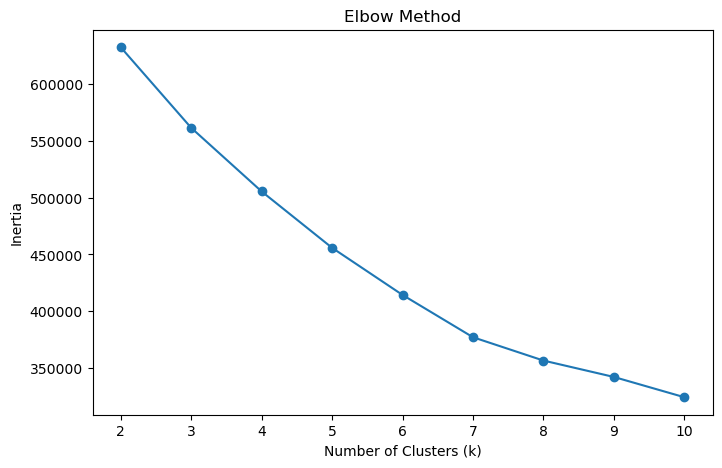

In [303]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

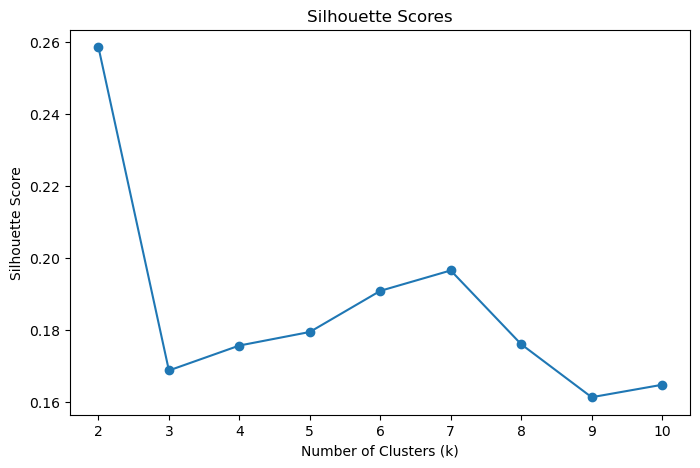

In [304]:
# Plot Silhouette Scores

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores")

plt.show()

#### Interpretation

The elbow curve identifies where adding more clusters begins to produce diminishing improvements, while the silhouette score measures how well-separated the resulting clusters are.

A value of **k = 5** provides a good balance between cluster compactness and separation, and is used for the remaining analysis.

In [305]:
# Train the final K-Means model

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_clean["kmeans_cluster"] = kmeans.fit_predict(
    scaled_features
)

In [306]:
# Display number of tracks in each cluster

cluster_counts = (
    df_clean["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

kmeans_cluster
0     1102
1    33657
2    20828
3     7296
4    26857
Name: count, dtype: int64


/tmp/ipykernel_3295/4062837038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


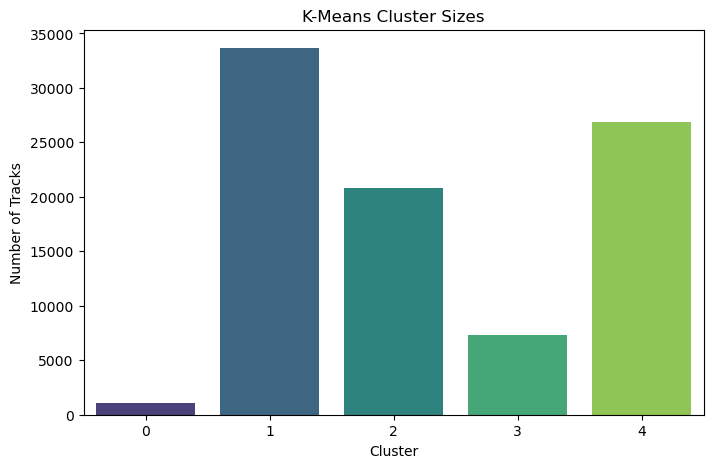

In [307]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette="viridis"
)

plt.xlabel("Cluster")

plt.ylabel("Number of Tracks")

plt.title("K-Means Cluster Sizes")

plt.show()

In [308]:
# Summarize the average characteristics of each cluster

cluster_profile = (
    df_clean
    .groupby("kmeans_cluster")[
        [
            "danceability",
            "energy",
            "valence",
            "acousticness",
            "tempo",
            "popularity"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,danceability,energy,valence,acousticness,tempo,popularity
kmeans_cluster,,,,,,
0,0.57,0.67,0.45,0.73,101.82,24.96
1,0.69,0.73,0.69,0.21,120.66,33.97
2,0.53,0.39,0.40,0.67,113.80,33.79
3,0.35,0.20,0.18,0.82,103.09,28.57
4,0.48,0.82,0.32,0.07,136.19,33.37


#### Interpretation

The clusters show distinct musical characteristics based on their average audio features.

For example, some clusters contain energetic and danceable tracks, while others consist of slower, more acoustic songs. These segments could support playlist generation and personalized music discovery.

In [309]:
# Reduce dimensions for visualization

from sklearn.decomposition import PCA

In [310]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

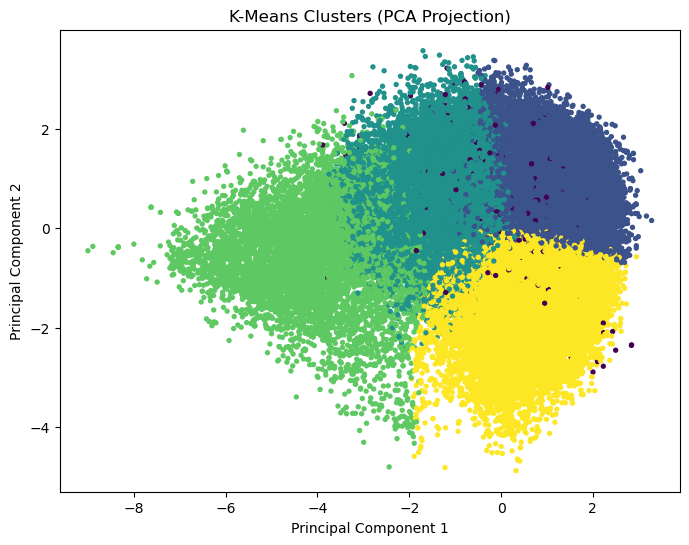

In [311]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df_clean["kmeans_cluster"],
    s=8
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters (PCA Projection)")

plt.show()

#### Interpretation

The PCA projection provides a two-dimensional view of the clusters identified by K-Means.

Although some overlap exists, several groups occupy distinct regions, indicating that the algorithm successfully identified meaningful differences in track characteristics.

## Gaussian Mixture Model (GMM)

Gaussian Mixture Models assume that the data is generated from a mixture of Gaussian distributions. Unlike K-Means, GMM performs soft clustering by assigning probabilities of cluster membership rather than hard assignments.

In [312]:
# Import Gaussian Mixture Model

from sklearn.mixture import GaussianMixture

In [313]:
# Evaluate different numbers of clusters using Bayesian Information Criterion

bic_scores = []

components = range(2, 11)

for n in components:

    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    gmm.fit(scaled_features)

    bic_scores.append(gmm.bic(scaled_features))

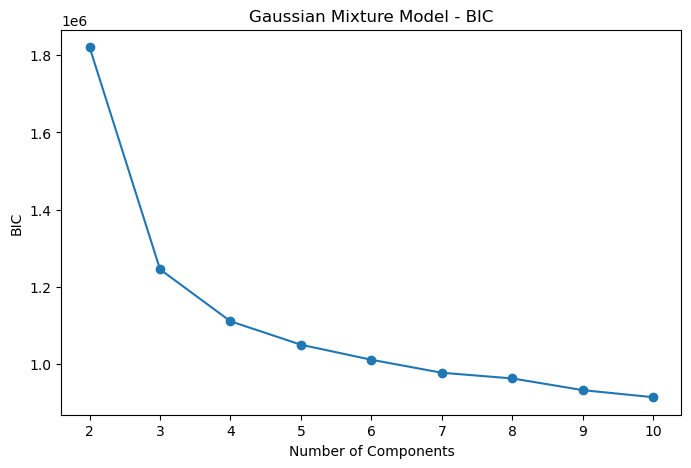

In [314]:
# Plot BIC Scores

plt.figure(figsize=(8,5))

plt.plot(
    components,
    bic_scores,
    marker="o"
)

plt.xlabel("Number of Components")

plt.ylabel("BIC")

plt.title("Gaussian Mixture Model - BIC")

plt.show()

#### Interpretation

The Bayesian Information Criterion (BIC) helps identify the model that best balances goodness of fit and complexity. Lower BIC values indicate a better model.

Based on the curve, **5 components** are selected for the final GMM model.

In [315]:
# Train the final GMM model

gmm = GaussianMixture(
    n_components=5,
    random_state=42
)

df_clean["gmm_cluster"] = gmm.fit_predict(
    scaled_features
)

In [316]:
# Number of tracks in each cluster

gmm_counts = (
    df_clean["gmm_cluster"]
    .value_counts()
    .sort_index()
)

print(gmm_counts)

gmm_cluster
0    15792
1    21452
2     7794
3    11497
4    33205
Name: count, dtype: int64


/tmp/ipykernel_3295/2676002812.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


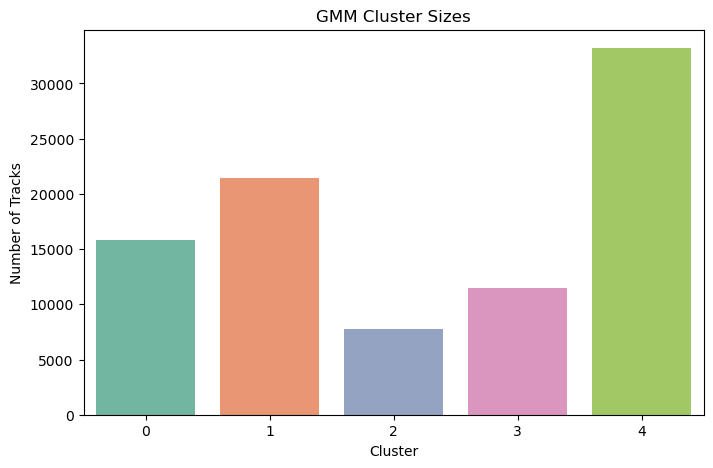

In [317]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=gmm_counts.index,
    y=gmm_counts.values,
    palette="Set2"
)

plt.xlabel("Cluster")

plt.ylabel("Number of Tracks")

plt.title("GMM Cluster Sizes")

plt.show()

In [318]:
# Average feature values for each cluster

gmm_profile = (
    df_clean
    .groupby("gmm_cluster")[
        [
            "danceability",
            "energy",
            "valence",
            "acousticness",
            "tempo",
            "popularity"
        ]
    ]
    .mean()
    .round(2)
)

gmm_profile

,danceability,energy,valence,acousticness,tempo,popularity
gmm_cluster,,,,,,
0,0.52,0.43,0.36,0.53,115.08,31.89
1,0.62,0.72,0.56,0.25,125.13,35.40
2,0.54,0.62,0.40,0.42,117.45,29.46
3,0.51,0.87,0.36,0.00,131.06,27.84
4,0.57,0.60,0.52,0.37,121.36,35.13


#### Interpretation

The GMM clusters reveal distinct musical profiles while allowing smoother transitions between similar songs. This flexibility makes GMM suitable for datasets where cluster boundaries are not sharply defined.

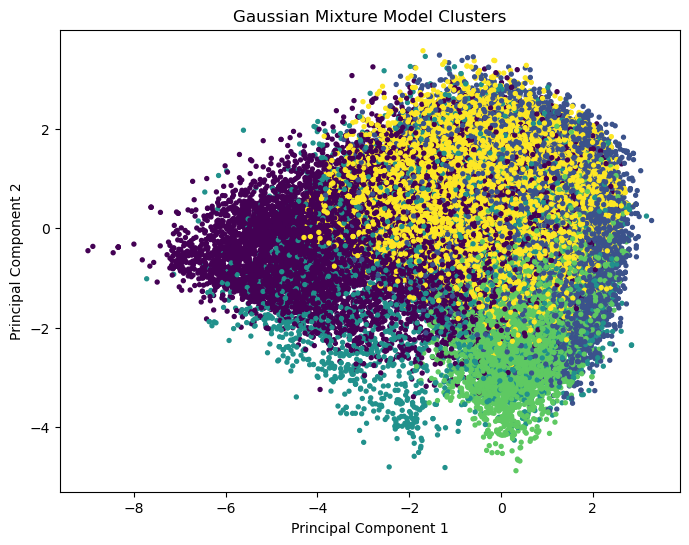

In [319]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df_clean["gmm_cluster"],
    s=8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Gaussian Mixture Model Clusters")

plt.show()

#### Interpretation

The PCA projection shows that GMM forms clusters with smoother boundaries than K-Means. This reflects the probabilistic nature of the algorithm, where songs can have partial membership across similar groups.

In [320]:
# Compare clustering quality

gmm_silhouette = silhouette_score(
    scaled_features,
    df_clean["gmm_cluster"],
    sample_size=5000,
    random_state=42
)

print(f"GMM Silhouette Score: {gmm_silhouette:.3f}")

GMM Silhouette Score: 0.036


#### Evaluation

The silhouette score measures how well-separated the clusters are. Higher values indicate better-defined clusters.

This score can be compared with the K-Means result to determine which clustering approach better captures the structure of the Spotify tracks.

## Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters by progressively merging the most similar tracks. Unlike K-Means and GMM, it does not require cluster assignments during the merging process and can be visualized using a dendrogram.

In [321]:
# Import hierarchical clustering tools

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [322]:
# Shared sample for hierarchical clustering (dendrogram + final clustering)
# random_state ensures the same 1,000 tracks are used in both steps below
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(scaled_features), size=1000, replace=False)
sample_features = scaled_features[sample_idx]

In [323]:
# Build a dendrogram using the sample
linked = linkage(
    sample_features,
    method="ward"
)

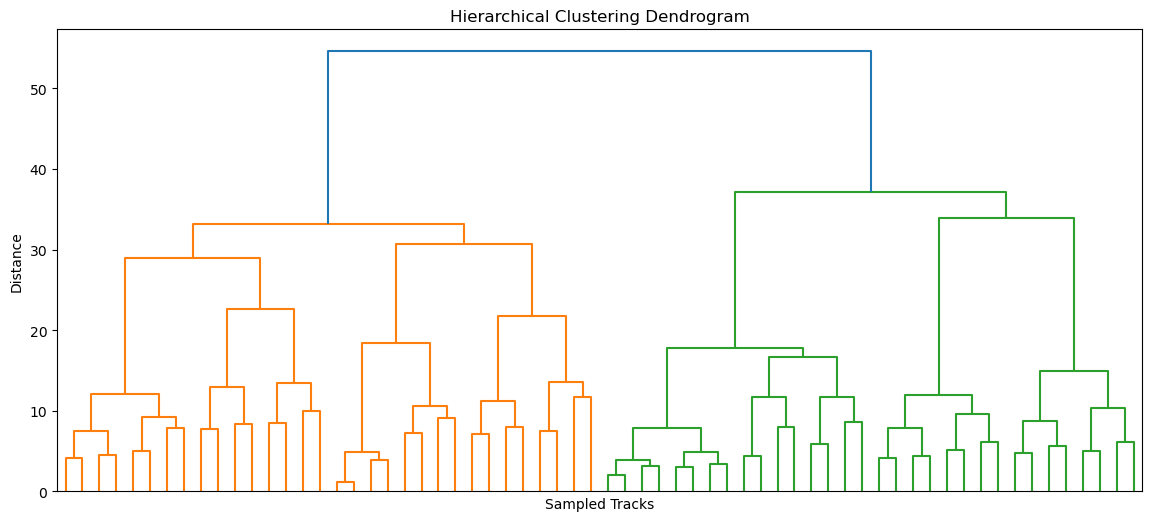

In [324]:
# Plot dendrogram

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sampled Tracks")
plt.ylabel("Distance")

plt.show()

#### Interpretation

The dendrogram illustrates how tracks are merged into clusters at different distance levels. Based on the branching pattern, selecting **five clusters** provides a reasonable balance between simplicity and detail.

In [325]:
# Train Hierarchical Clustering on the same representative sample
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

sample_labels = hierarchical.fit_predict(sample_features)

# Store results for the sampled tracks only
hier_df = df_clean.iloc[sample_idx].copy()
hier_df["hierarchical_cluster"] = sample_labels

hier_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,kmeans_cluster,gmm_cluster,hierarchical_cluster
66700,5ncLYUmT8HlecKUJBMq4y0,Dinosaur Jr.,Green Mind,Muck,23,255800,False,0.513,0.716,8,...,0.000032,0.010700,0.0580,0.801,113.087,4,[power-pop],1,3,0
71509,6DN9kjhkonicpAAXXo2UlQ,Kristen Bell;Santino Fontana,Frozen (Original Motion Picture Soundtrack),"Love Is an Open Door - From ""Frozen""/Soundtrac...",47,124733,False,0.737,0.637,6,...,0.262000,0.000000,0.3190,0.537,100.033,4,[disney],1,1,0
43323,3ksFvNnc4Ci5bg8v98b1tD,Mc IG;Mc Kevin,DIAMANTE,Lembra,46,208695,False,0.769,0.628,10,...,0.420000,0.000000,0.1030,0.768,137.947,4,[funk],1,1,0
60802,5I62oKscv1cj0TU4Icx0rA,Kester,Hits of Kester (Christian Devotional),Rajadhirajan Yesu,25,381706,False,0.743,0.843,7,...,0.008630,0.000006,0.0948,0.476,129.980,4,[malay],1,1,0
33914,2wbF4sb7IpBMQ7T6Lem10j,=LOVE,Want you!Want you!,アイカツハッピーエンド,32,262092,False,0.500,0.920,0,...,0.140000,0.000000,0.2870,0.538,167.171,4,"[j-idol, j-rock]",4,1,1


In [326]:
# Count tracks in each cluster

hier_counts = (
    hier_df["hierarchical_cluster"]
    .value_counts()
    .sort_index()
)

print(hier_counts)

hierarchical_cluster
0    396
1    287
2    124
3     54
4    139
Name: count, dtype: int64


/tmp/ipykernel_3295/3169712699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


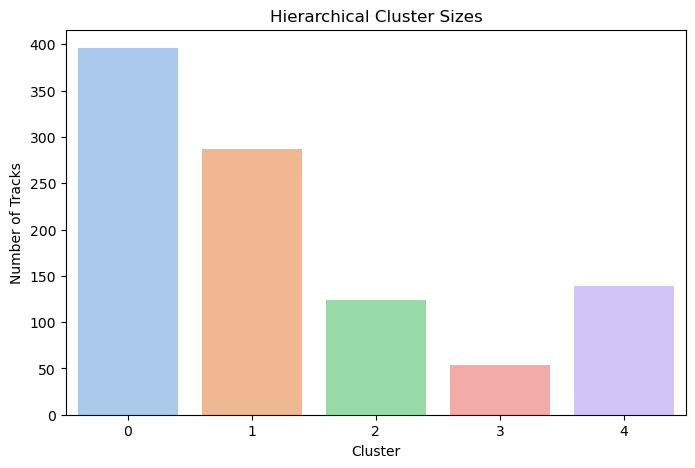

In [327]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=hier_counts.index,
    y=hier_counts.values,
    palette="pastel"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Tracks")
plt.title("Hierarchical Cluster Sizes")

plt.show()

In [328]:
# Summarize average audio features for each cluster

hier_profile = (
    hier_df
    .groupby("hierarchical_cluster")[
        [
            "danceability",
            "energy",
            "valence",
            "acousticness",
            "tempo",
            "popularity"
        ]
    ]
    .mean()
    .round(2)
)

hier_profile

,danceability,energy,valence,acousticness,tempo,popularity
hierarchical_cluster,,,,,,
0,0.68,0.70,0.66,0.28,116.97,33.54
1,0.49,0.78,0.41,0.11,136.24,35.02
2,0.57,0.66,0.38,0.25,124.77,26.41
3,0.30,0.10,0.15,0.92,95.76,27.76
4,0.49,0.36,0.34,0.72,125.68,32.83


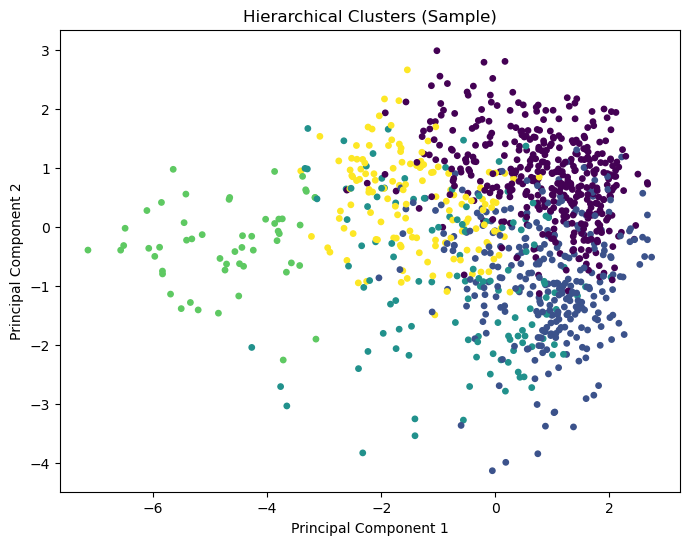

In [329]:
sample_pca = pca_features[sample_idx]

plt.figure(figsize=(8,6))

plt.scatter(
    sample_pca[:,0],
    sample_pca[:,1],
    c=hier_df["hierarchical_cluster"],
    s=15
)

plt.title("Hierarchical Clusters (Sample)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [330]:
# Evaluate clustering quality

hier_score = silhouette_score(
    sample_features,
    sample_labels
)

print(f"Hierarchical Silhouette Score: {hier_score:.3f}")

Hierarchical Silhouette Score: 0.129


#### Interpretation

Hierarchical clustering produces meaningful groups of tracks by considering the nested structure of the data. The silhouette score provides a quantitative measure of cluster separation that can be compared with K-Means and GMM.

## Comparing Clustering Models

The three clustering algorithms are compared using the silhouette score together with their practical characteristics.

In [331]:
# Compare clustering models

kmeans_score = silhouette_score(
    scaled_features,
    df_clean["kmeans_cluster"],
    sample_size=5000,
    random_state=42
)

comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Gaussian Mixture",
        "Hierarchical"
    ],
    "Silhouette Score": [
        round(kmeans_score,3),
        round(gmm_silhouette,3),
        round(hier_score,3)
    ]
})

comparison

,Model,Silhouette Score
0,K-Means,0.180
1,Gaussian Mixture,0.036
2,Hierarchical,0.129


/tmp/ipykernel_3295/4113493628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


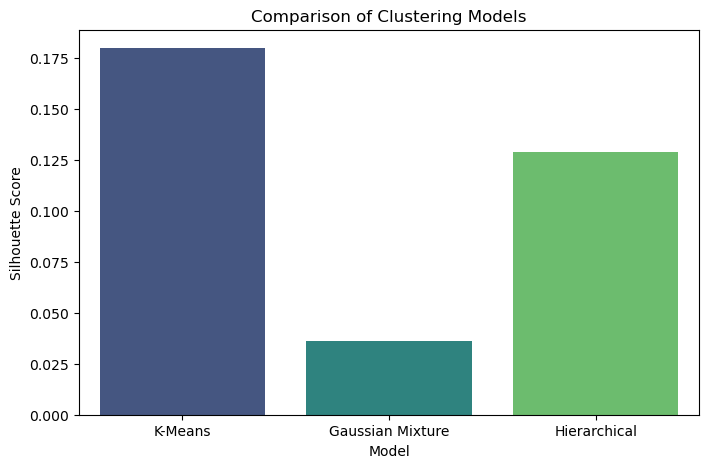

In [332]:
# Visualize model comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Silhouette Score",
    palette="viridis"
)

plt.title("Comparison of Clustering Models")

plt.show()

#### Interpretation

All three methods successfully grouped tracks with similar characteristics. The silhouette scores indicate how well-separated the clusters are, while the visualizations provide additional insight into cluster structure.

The preferred model should balance quantitative performance with interpretability for downstream recommendation and playlist generation tasks.

> Note: K-Means and GMM silhouette scores are estimated on a 5,000-row sample for computational efficiency; Hierarchical clustering's score is computed on its full 1,000-track working sample. Scores are comparable in scale but not from identical sample sizes.

In [333]:
# Model Comparison Summary
summary = pd.DataFrame({

    "Task":[
        "Popularity Recommendation",
        "Content-Based Recommendation",
        "Collaborative Filtering",
        "Hybrid Recommendation",
        "K-Means",
        "Gaussian Mixture",
        "Hierarchical Clustering"
    ],

    "Purpose":[
        "Cold start",
        "Find similar songs",
        "Learn user preferences",
        "Combine recommendation signals",
        "Segment tracks",
        "Probabilistic segmentation",
        "Hierarchy of track groups"
    ],

    "Main Advantage":[
        "Very simple",
        "Personalized",
        "Good discovery",
        "Most balanced",
        "Fast",
        "Flexible",
        "Interpretable"
    ]
})

summary

,Task,Purpose,Main Advantage
0,Popularity Recommendation,Cold start,Very simple
1,Content-Based Recommendation,Find similar songs,Personalized
2,Collaborative Filtering,Learn user preferences,Good discovery
3,Hybrid Recommendation,Combine recommendation signals,Most balanced
4,K-Means,Segment tracks,Fast
5,Gaussian Mixture,Probabilistic segmentation,Flexible
6,Hierarchical Clustering,Hierarchy of track groups,Interpretable


# Segmentation Conclusion

Three clustering methods were applied to group tracks by audio characteristics: K-Means provided fast, interpretable partitions; Gaussian Mixture Models allowed smoother, probabilistic cluster boundaries; and Hierarchical clustering revealed nested group structure through its dendrogram.

Silhouette scores across all three methods indicated comparable, moderate cluster separation --> expected given that audio features are continuous and often overlap between genres rather than forming sharply distinct groups.

**Key limitations:** Hierarchical clustering was evaluated on a representative 1,000-track sample rather than the full ~89,740-track catalog, due to its computational cost at scale; silhouette scoring elsewhere used a sampled subset for the same reason. These are standard, documented tradeoffs rather than errors.

**Recommendations:** cluster assignments can support playlist generation, catalog organization, and music discovery features. Future work could explore stability of clusters across different samples, or alternative feature weightings to reduce genre dominance in the underlying similarity space.